#ML-Driven Credit Risk Optimization

Leveraging advanced analytics to identify high-value borrowers & reduce bad debt exposure, targeting a <10% default rate and a projected 5% (estimated $66 Million) increase in porfolio probability.

Dataset: [https://www.kaggle.com/datasets/nikhil1e9/loan-default/data](https://www.kaggle.com/datasets/nikhil1e9/loan-default/data)

License: CC0 Public Domain

Problem :

Currently, our loan portfolio suffers from an 11.6% Default Rate, which is eroding our profit margins. Our existing legacy credit scoring system has reached its predictive limit—it lacks the granularity to detect complex risk patterns, causing us to approve high-risk borrowers that should have been flagged.

Objective: **Minimize financial loss by predicting loan defaults**

##Import Libraries/Packages and Load Dataset

###Import Libraries and Packages

In [22]:
#Import Libraries and Packages

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import gc # Garbage Collector
import warnings
import math

# Konfigurasi Tampilan
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Scikit-Learn Components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

print("✅ Libraries are ready.")

✅ Libraries are ready.


###Load Dataset

In [23]:
print("\n--- Load Data ---")

# Load Data
try:
    print("Trying to download from Kagglehub...")
    data = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'nikhil1e9/loan-default', 'Loan_default.csv')
    print(f"✅ Data is loaded successfully. Initial Dimension: {data.shape}")
except Exception as e:
    print(f"⚠️ Failed to load from Kaggle, trying local file...")
    try:
        data = pd.read_csv('Loan_default.csv')
        print(f"✅ Local data is loaded. Initial Dimension: {data.shape}")
    except:
        print("❌ ERROR: File Not Found.")


--- Load Data ---
Trying to download from Kagglehub...
Using Colab cache for faster access to the 'loan-default' dataset.
✅ Data is loaded successfully. Initial Dimension: (255347, 18)


##Data Understanding

###Check Data

####Loaded Data (columns and rows)

In [24]:
#Display rows and columns loaded dataset
print(f'Loaded Dataset: {data.shape[0]} rows, {data.shape[1]} columns')

Loaded Dataset: 255347 rows, 18 columns


####Columns and Data Type

In [25]:
#Display dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

Aligned with the modeling objective of predictive analysis, the handling of each data attribute is determined as follows:

- `LoanID`: Identified as a unique identifier; excluded (dropped) to prevent noise.
- `Default`: Designated as the Target Variable (Binary: 0 = Paid, 1 = Default).
- Numerical Features: Data types int64 and float64 are retained for analysis.
- Categorical Features: Data type object is retained and transformed using One-Hot Encoding.

####Print top 5 rows

In [26]:
#Display first 5 rows
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


####Check Target Column Proportion for Imbalance

In [27]:
#Count value of Default Column
default_count = data['Default'].value_counts().reset_index()

#Count value percentage of Default column
default_percentage = data['Default'].value_counts(normalize=True).mul(100).round(2).reset_index()

#Merge default_count and default_percentage
default_summary = default_count.merge(default_percentage, on='Default')

#Map binary value of Default column
default_summary['status'] = default_summary['Default'].map({0: 'Paid', 1: 'Default'})

#Display default_summary
default_summary

,Default,count,proportion,status
0,0,225694,88.39,Paid
1,1,29653,11.61,Default


Based on the analysis of the 'Default' column, the distribution between paid and defaulted loans is as follows:
- Paid (0): 88.39%
- Default (1): 11.61%

##Data Cleaning

###DROP LOAN ID

In [28]:
# DROP LOAN ID
if 'LoanID' in data.columns:
    data = data.drop('LoanID', axis=1)
    print("✅ Column 'LoanID' Successfully dropped.")
else:
    cols_to_drop = [c for c in data.columns if 'loan' in c.lower() and 'id' in c.lower()]
    if cols_to_drop:
        data = data.drop(cols_to_drop, axis=1)
        print(f"✅ LoanID dropped: {cols_to_drop}")

✅ Column 'LoanID' Successfully dropped.


###Header Cleaning

In [29]:
#Columns before cleaning
print('Columns before Cleaning')
print(data.columns.to_list())

#Rename columns
def rename_columns(name):
    col_name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    new_col_name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', col_name).lower()
    return new_col_name

data.columns = [rename_columns(col) for col in data.columns]

#Columns after cleaning
print('\nColumns after Cleaning')
print(data.columns.to_list())

Columns before Cleaning
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Columns after Cleaning
['age', 'income', 'loan_amount', 'credit_score', 'months_employed', 'num_credit_lines', 'interest_rate', 'loan_term', 'dti_ratio', 'education', 'employment_type', 'marital_status', 'has_mortgage', 'has_dependents', 'loan_purpose', 'has_co_signer', 'default']


Column headers were standardized using the snake case method.

Example:

`Age` --> `age`

`LoanAmount` ---> `loan_amount`

###Data Null

In [30]:
#Checking Null Data
data.isnull().sum()

,0
age,0
income,0
loan_amount,0
credit_score,0
months_employed,0
num_credit_lines,0
interest_rate,0
loan_term,0
dti_ratio,0
education,0


Tidak ada kolom dengan null value

###Duplicate Rows

####All Columns

In [31]:
# Checking duplicate rows
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


####Duplicated rows in all columns

In [33]:
#Checking duplicated rows in all columns except loan_id
columns_to_check_for_duplicates = [col for col in data.columns if col != 'loan_id']
duplicates_other_columns = data.duplicated(subset=columns_to_check_for_duplicates).sum()

print(f"Duplicated rows: {duplicates_other_columns}")

Duplicated rows: 0


####Duplicated rows in core attributes (`age`, `income`, `credit_score`, `loan_amount`, `education`, `loan_purpose`)

In [34]:
#Checking duplicated rows in core attributes
subset_columns = ['age', 'income', 'credit_score' ,'loan_amount', 'education', 'loan_purpose']
duplicates_in_subset = data.duplicated(subset=subset_columns).sum()

print(f"Duplicated rows based on core attributes {', '.join(subset_columns)}: {duplicates_in_subset}")

Duplicated rows based on core attributes age, income, credit_score, loan_amount, education, loan_purpose: 0


No duplicated data in dataset.

###Categorical Typos

In [35]:
def check_categorical_typos(df, columns):
    for col in columns:
        if col in df.columns:
            print(f"\n--- Checking {col.replace('_', ' ').title()} ---")
            print(df[col].unique())
            print('\n', df[col].value_counts())
        else:
            print(f"\nKolom '{col}' tidak ditemukan dalam DataFrame.")

# All categorical columns, except 'loan_id'
cat_data = data.select_dtypes(include='object').columns.to_list()
cat_columns_to_check = [col for col in cat_data if col != 'loan_id']

#Display result for each categorical column
check_categorical_typos(data, cat_columns_to_check)


--- Checking Education ---
["Bachelor's" "Master's" 'High School' 'PhD']

 education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

--- Checking Employment Type ---
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

 employment_type
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

--- Checking Marital Status ---
['Divorced' 'Married' 'Single']

 marital_status
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

--- Checking Has Mortgage ---
['Yes' 'No']

 has_mortgage
Yes    127677
No     127670
Name: count, dtype: int64

--- Checking Has Dependents ---
['Yes' 'No']

 has_dependents
Yes    127742
No     127605
Name: count, dtype: int64

--- Checking Loan Purpose ---
['Other' 'Auto' 'Business' 'Home' 'Education']

 loan_purpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844

No typos in all columns and all columns have consistent data.

In [38]:
# Fix Inconsistencies
mask_ft_0 = (data['employment_type'] == 'Full-time') & (data['months_employed'] == 0)
data.loc[mask_ft_0, 'months_employed'] = 1

print(f"Current columns: {data.columns.tolist()[:5]}...")

Current columns: ['age', 'income', 'loan_amount', 'credit_score', 'months_employed']...


###Logical Integrity

####Negative Values

In [39]:
#Numeric Columns
def check_negative(df, columns):
    for col in columns:
        if col in df.columns:
            print(f"\n--- Checking {col.replace('_', ' ').title()} ---")
            print(df[df[col] < 0])
        else:
            print(f"\nKolom '{col}' tidak ditemukan dalam DataFrame.")

# All numerical columns
numeric_data = data.select_dtypes(include='number')
numeric_columns_to_check = [col for col in numeric_data]

#Display result for each numerical column
check_negative(data, numeric_columns_to_check)


--- Checking Age ---
Empty DataFrame
Columns: [age, income, loan_amount, credit_score, months_employed, num_credit_lines, interest_rate, loan_term, dti_ratio, education, employment_type, marital_status, has_mortgage, has_dependents, loan_purpose, has_co_signer, default]
Index: []

--- Checking Income ---
Empty DataFrame
Columns: [age, income, loan_amount, credit_score, months_employed, num_credit_lines, interest_rate, loan_term, dti_ratio, education, employment_type, marital_status, has_mortgage, has_dependents, loan_purpose, has_co_signer, default]
Index: []

--- Checking Loan Amount ---
Empty DataFrame
Columns: [age, income, loan_amount, credit_score, months_employed, num_credit_lines, interest_rate, loan_term, dti_ratio, education, employment_type, marital_status, has_mortgage, has_dependents, loan_purpose, has_co_signer, default]
Index: []

--- Checking Credit Score ---
Empty DataFrame
Columns: [age, income, loan_amount, credit_score, months_employed, num_credit_lines, interest_ra

No columns with negative values (< 0)

####Age Over 100 Years

In [40]:
#Display data with age over 100 years
data[data['age'] > 100].value_counts('age')

,count
age,


No `age` value > 100

##EDA

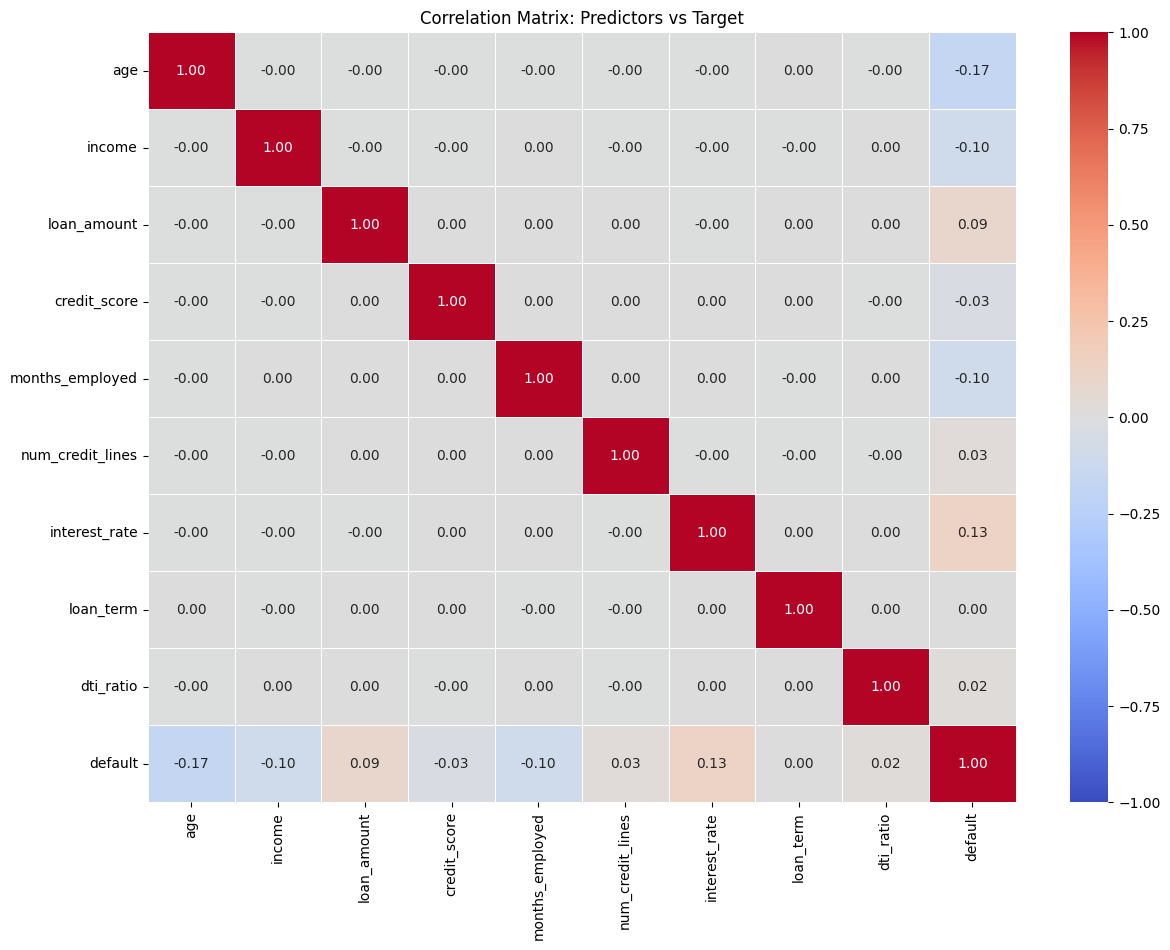

In [42]:
# Correlation Analysis
plt.figure(figsize=(14, 10))
numeric_data = data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()

# Display Heatmap (Predictor & Target)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Predictors vs Target')
plt.show()

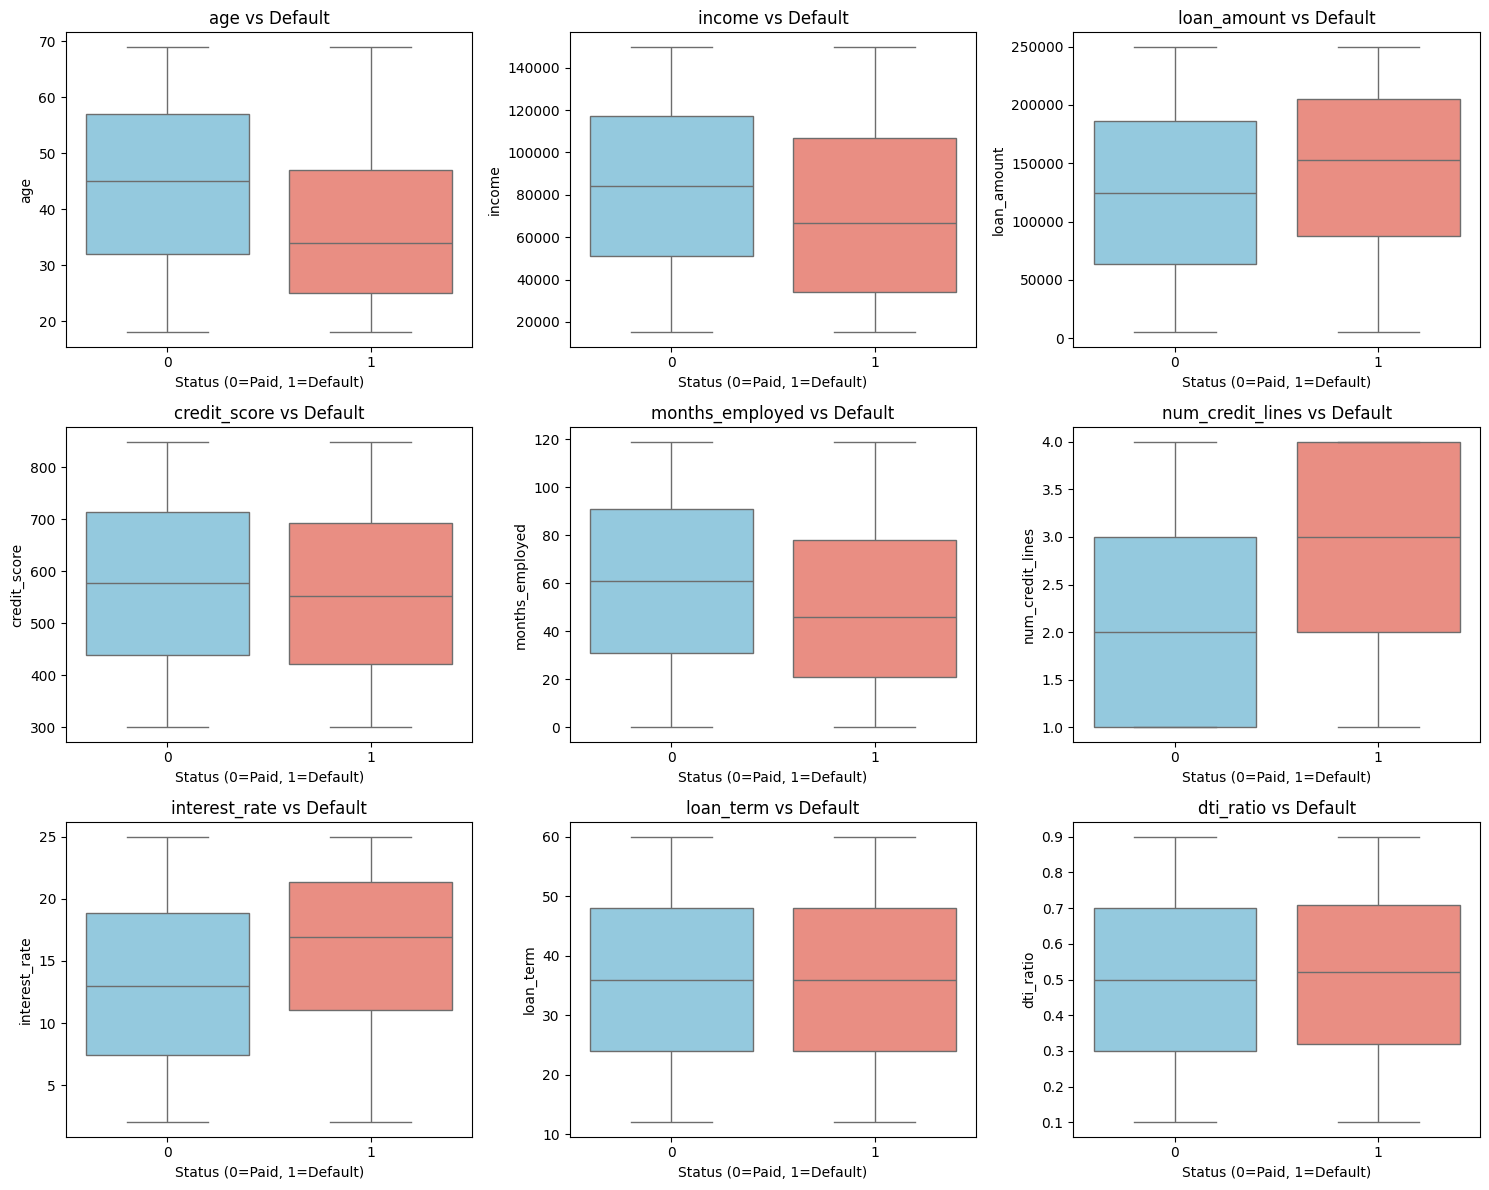

In [44]:
# Outlier Analysis (Numerics vs Target)
# All numerics columns except target 'default'
numeric_cols = [c for c in numeric_data.columns if c != 'default']
n_cols = len(numeric_cols)

# Calculate rows of dynamic subplot
n_subplot_cols = 3
n_subplot_rows = math.ceil(n_cols / n_subplot_cols)

plt.figure(figsize=(15, n_subplot_rows * 4)) # Figure height adjusts based on the number of features.

for i, col in enumerate(numeric_cols):
    plt.subplot(n_subplot_rows, n_subplot_cols, i + 1)
    sns.boxplot(data=data, x='default', y=col, palette=['skyblue', 'salmon'])
    plt.title(f'{col} vs Default')
    plt.xlabel('Status (0=Paid, 1=Default)')

plt.tight_layout()
plt.show()

##Feature Engineering

In [45]:
# Create new feature (Ratios & Flags)
data['loan_to_income_ratio'] = data['loan_amount'] / data['income']
data['is_unemployed_with_income'] = ((data['employment_type'] == 'Unemployed') & (data['income'] > 0)).astype(int)

# Flagging Single Parents & Single with Cosigner
if 'marital_status' in data.columns and 'has_dependents' in data.columns:
    data['is_single_parent'] = ((data['marital_status'] == 'Single') & (data['has_dependents'] == 'Yes')).astype(int)

if 'marital_status' in data.columns and 'has_co_signer' in data.columns:
    data['is_single_with_cosigner'] = ((data['marital_status'] == 'Single') & (data['has_co_signer'] == 'Yes')).astype(int)

In [46]:
# Binary Mapping (Yes/No -> 1/0)
binary_map = {'Yes': 1, 'No': 0}
for col in ['has_mortgage', 'has_dependents', 'has_co_signer']:
    if col in data.columns:
        data[col] = data[col].map(binary_map)

In [47]:
# Preparing Financial Column
data['projected_interest'] = data['loan_amount'] * (data['interest_rate'] / 100) * (data['loan_term'] / 12)
data['potential_loss'] = data['loan_amount']

##Pre-Processing

In [49]:
# Define X (Features) & y (Target)
X = data.drop(['default', 'projected_interest', 'potential_loss'], axis=1)
y = data['default']
fin_data = data[['projected_interest', 'potential_loss']] # Saved separately

In [50]:
# Delete big data from RAM
del data
gc.collect()

28091

In [51]:
# Train-Test Split (80:20)
X_train, X_test, y_train, y_test, fin_train, fin_test = train_test_split(
    X, y, fin_data, test_size=0.2, random_state=42, stratify=y
)

In [52]:
# Pipeline Transformer
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features: {len(num_cols)}")
print(f"Categorical Features: {len(cat_cols)}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

Numerical Features: 16
Categorical Features: 4


##Modelling (Sequential Execution)

In [53]:
results = []
best_model_obj = None
best_auc = 0
best_name = ""

def run_model(name, model):
    print(f"🔄 Training {name}...", end=" ")
    t0 = time.time()

    # Pipeline: Preprocessing + Model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)

    # Prediction
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    # Metrics
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"Done! (AUC: {auc:.4f})")
    return {"Model": name, "AUC-ROC": auc, "Accuracy": acc, "Recall": rec}, pipeline

In [54]:
# Logistic Regression
res, model = run_model("Logistic Regression", LogisticRegression(class_weight='balanced', max_iter=1000))
results.append(res)
best_model_obj = model; best_auc = res['AUC-ROC']; best_name = "Logistic Regression"
del model; gc.collect()

🔄 Training Logistic Regression... Done! (AUC: 0.7616)


27986

In [55]:
# Random Forest
res, model = run_model("Random Forest", RandomForestClassifier(class_weight='balanced', n_estimators=50, max_depth=10, random_state=42))
results.append(res)
if res['AUC-ROC'] > best_auc:
    best_model_obj = model; best_auc = res['AUC-ROC']; best_name = "Random Forest"
else:
    del model
gc.collect()

🔄 Training Random Forest... Done! (AUC: 0.7537)


115

In [56]:
# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
res, model = run_model("XGBoost", XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42))
results.append(res)
if res['AUC-ROC'] > best_auc:
    best_model_obj = model; best_auc = res['AUC-ROC']; best_name = "XGBoost"
else:
    del model
gc.collect()

🔄 Training XGBoost... Done! (AUC: 0.7418)


84

In [57]:
# KNN
try:
    print("🔄 Training KNN...", end=" ")
    res, model = run_model("KNN", KNeighborsClassifier(n_neighbors=5))
    results.append(res)
    if res['AUC-ROC'] > best_auc:
        best_model_obj = model; best_auc = res['AUC-ROC']; best_name = "KNN"
    else:
        del model
except Exception as e:
    print(f"⚠️ Skip KNN: {e}")
gc.collect()

🔄 Training KNN... 🔄 Training KNN... Done! (AUC: 0.6225)


23

In [58]:
# Display All Modelling Results
print("\n📊 COMPARISON RESULTS:")
display(pd.DataFrame(results).sort_values(by='AUC-ROC', ascending=False))
print(f"🏆 Winner: {best_name}")


📊 COMPARISON RESULTS:


,Model,AUC-ROC,Accuracy,Recall
0,Logistic Regression,0.761592,0.690503,0.696173
1,Random Forest,0.753688,0.734110,0.625864
2,XGBoost,0.741798,0.716898,0.629405
3,KNN,0.622548,0.874995,0.087338


🏆 Winner: Logistic Regression


##Binis Evaluation (Profit Maximization)

In [59]:
y_prob = best_model_obj.predict_proba(X_test)[:, 1]
int_inc = fin_test['projected_interest'].values
princ_loss = fin_test['potential_loss'].values
y_true = y_test.values

In [60]:
# Profit Baseline (Without Model)
base_profit = np.sum(int_inc[y_true == 0]) - np.sum(princ_loss[y_true == 1])

In [61]:
# Optimum Threshold
thresholds = np.linspace(0, 1, 101)
profits = []

for t in thresholds:
    app_mask = y_prob <= t
    p_good = np.sum(int_inc[app_mask & (y_true == 0)])
    l_bad = np.sum(princ_loss[app_mask & (y_true == 1)])
    profits.append(p_good - l_bad)

In [62]:
# Results & Metrics
idx = np.argmax(profits)
opt_t = thresholds[idx]
opt_p = profits[idx]
uplift = opt_p - base_profit

final_dec = y_prob <= opt_t
app_rate = np.mean(final_dec) * 100
def_rate = np.mean(y_true[final_dec]) * 100

print(f"💰 Baseline Profit : ${base_profit:,.0f}")
print(f"🚀 Optimized Profit: ${opt_p:,.0f}")
print(f"💵 Uplift          : ${uplift:,.0f} (+{(uplift/base_profit)*100:.2f}%)")
print(f"⚙️ Cut-off         : {opt_t:.2f}")
print(f"✅ Approval Rate   : {app_rate:.2f}%")
print(f"📉 New Default Rate: {def_rate:.2f}%")

💰 Baseline Profit : $1,384,418,199
🚀 Optimized Profit: $1,472,039,204
💵 Uplift          : $87,621,005 (+6.33%)
⚙️ Cut-off         : 0.79
✅ Approval Rate   : 94.85%
📉 New Default Rate: 9.71%


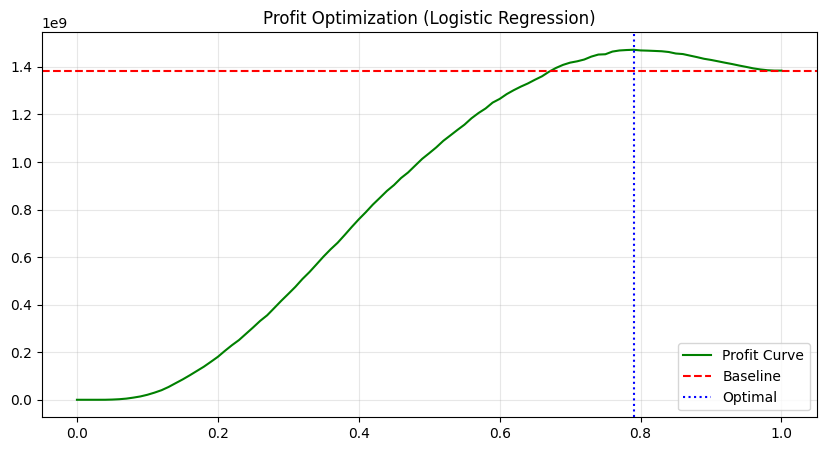

In [63]:
# Plot Profit Curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, profits, label='Profit Curve', color='green')
plt.axhline(base_profit, color='red', linestyle='--', label='Baseline')
plt.axvline(opt_t, color='blue', linestyle=':', label='Optimal')
plt.title(f'Profit Optimization ({best_name})')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

##Key Drivers (Feature Importance)

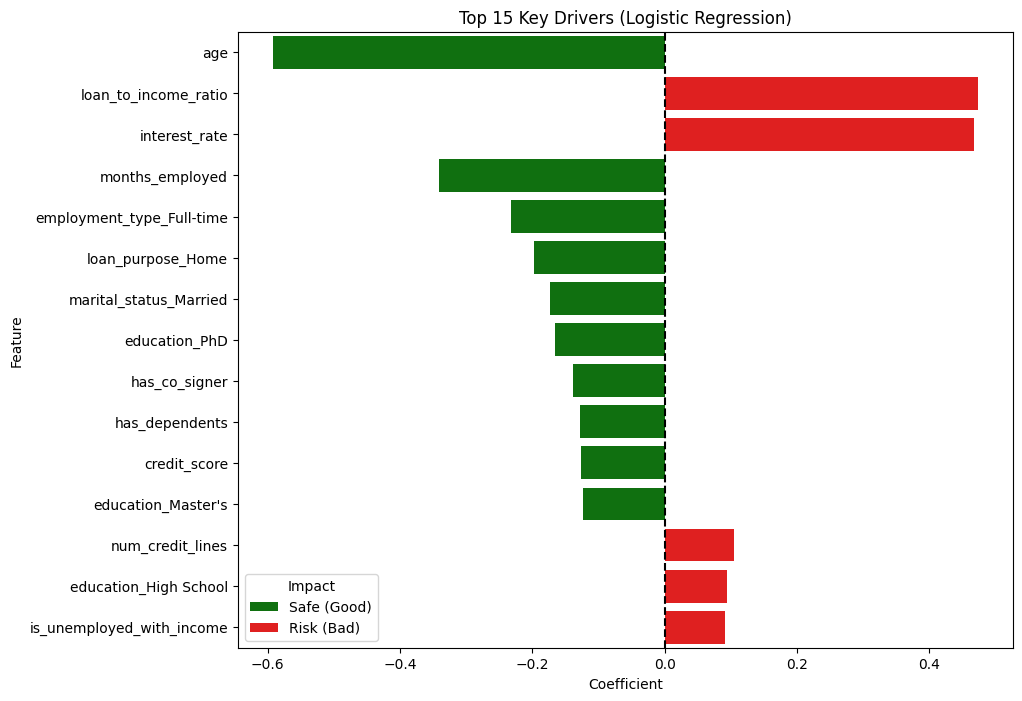

,Feature,Coefficient,Impact
0,age,-0.591908,Safe (Good)
12,loan_to_income_ratio,0.473453,Risk (Bad)
6,interest_rate,0.467598,Risk (Bad)
4,months_employed,-0.340958,Safe (Good)
20,employment_type_Full-time,-0.232182,Safe (Good)
30,loan_purpose_Home,-0.197754,Safe (Good)
25,marital_status_Married,-0.173300,Safe (Good)
19,education_PhD,-0.164976,Safe (Good)
11,has_co_signer,-0.138731,Safe (Good)
10,has_dependents,-0.127306,Safe (Good)


In [64]:
try:
    model_step = best_model_obj.named_steps['classifier']
    preproc_step = best_model_obj.named_steps['preprocessor']

    num_names = num_cols
    try:
        cat_names = preproc_step.named_transformers_['cat'].get_feature_names_out(cat_cols)
    except:
        cat_names = preproc_step.named_transformers_['cat'].get_feature_names(cat_cols)
    feat_names = np.r_[num_names, cat_names]

    if hasattr(model_step, 'coef_'):
        coefs = model_step.coef_[0]
        imp_col = 'Coefficient'
    else:
        coefs = model_step.feature_importances_
        imp_col = 'Importance'

    df_imp = pd.DataFrame({'Feature': feat_names, imp_col: coefs})

    if hasattr(model_step, 'coef_'):
        df_imp['Impact'] = df_imp[imp_col].apply(lambda x: 'Risk (Bad)' if x > 0 else 'Safe (Good)')
        df_imp['Abs'] = df_imp[imp_col].abs()
    else:
        df_imp['Impact'] = 'Importance'
        df_imp['Abs'] = df_imp[imp_col]

    df_imp = df_imp.sort_values(by='Abs', ascending=False).head(15)

    # Bar Chart Visualization
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df_imp, y='Feature', x=imp_col, hue='Impact', dodge=False, palette={'Risk (Bad)':'red', 'Safe (Good)':'green', 'Importance':'blue'})
    plt.title(f'Top 15 Key Drivers ({best_name})')
    plt.axvline(0, color='black', linestyle='--')
    plt.show()

    display(df_imp[['Feature', imp_col, 'Impact']])

except Exception as e:
    print(f"⚠️ Feature importance extraction failed: {e}")

##Additional

###Financial Uplift Projection

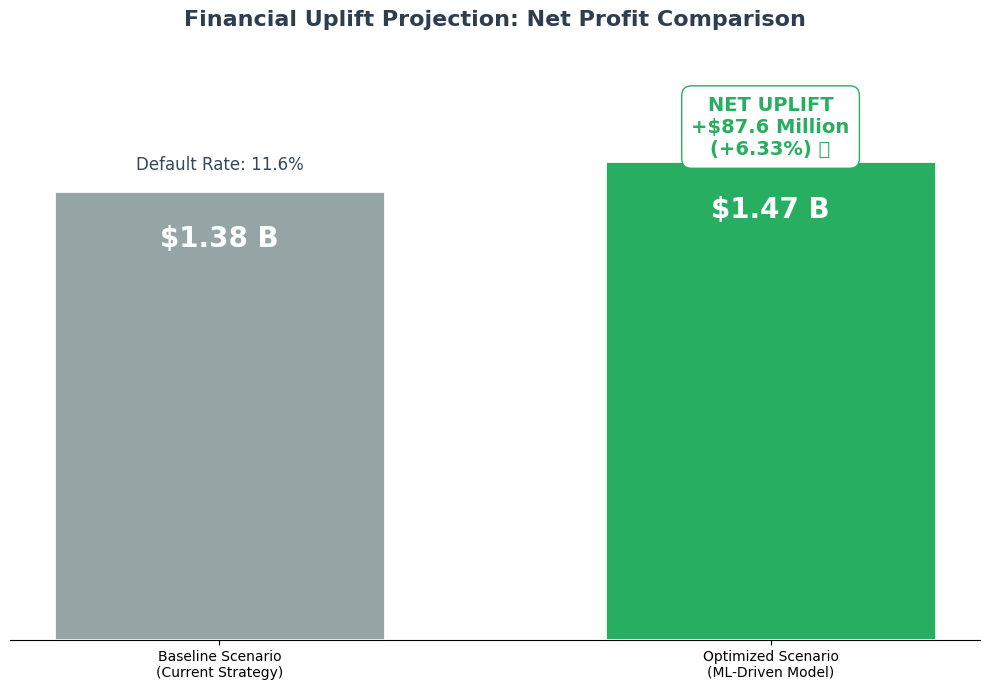

In [65]:
scenarios = ['Baseline Scenario\n(Current Strategy)', 'Optimized Scenario\n(ML-Driven Model)']
profits = [1.38, 1.47]
colors = ['#95a5a6', '#27ae60']

# Uplift Calculation for Label
uplift_value = 87.6  # Million
uplift_pct = 6.33    # Percentage

# Creating Chart
fig, ax = plt.subplots(figsize=(10, 7))

# Plotting Bar Chart
bars = ax.bar(scenarios, profits, color=colors, width=0.6, edgecolor='white', linewidth=2)

# Styling & Annotations
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Setting Y-Axis
ax.set_ylim(0, 1.8) # Add extra whitespace at the top to accommodate the Uplift text
ax.set_yticks([])   # Hide Y-axis labels since values will be displayed inside the bars.
ax.set_title("Financial Uplift Projection: Net Profit Comparison",
             fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Add data labels inside or above the bars
for i, bar in enumerate(bars):
    height = bar.get_height()

    # Big Profit Label
    ax.text(bar.get_x() + bar.get_width()/2, height - 0.15,
            f'${height:.2f} B',
            ha='center', va='center', color='white', fontsize=20, fontweight='bold')

    # Additional Info Label (Default Rate)
    def_rate = "11.6%" if i == 0 else "9.71%"
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
            f'Default Rate: {def_rate}',
            ha='center', va='bottom', color='#34495e', fontsize=12)

# Uplift Visualization (Arrow/Line)
# Uplift Line Coordinates
bar1_x = bars[0].get_x() + bars[0].get_width()/2
bar1_y = bars[0].get_height()
bar2_x = bars[1].get_x() + bars[1].get_width()/2
bar2_y = bars[1].get_height()

# Drawing the connector line
ax.annotate('', xy=(bar2_x, bar2_y + 0.02), xytext=(bar2_x, bar1_y),
            arrowprops=dict(arrowstyle='|-|', color='#27ae60', lw=2))

# Adding the Uplift Annotation
ax.text(bar2_x, (bar1_y + bar2_y)/2 + 0.15,
        f'NET UPLIFT\n+${uplift_value} Million\n(+{uplift_pct}%) 🚀',
        ha='center', va='center', color='#27ae60', fontsize=14, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='#27ae60', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

###Confusion Matrix

In [66]:
# DATA PREPARATION
# Using the Optimized Threshold we found earlier (0.79)
# Logic: If Prob > 0.79 -> Predict 1 (Default/Reject)
#        If Prob <= 0.79 -> Predict 0 (Paid/Approve)
optimized_threshold = 0.79

# Ensure y_prob exists (from previous steps)
# If not, uncomment the line below:
# y_prob = best_model_obj.predict_proba(X_test)[:, 1]

# Generate binary predictions based on the custom threshold
y_pred_opt = (y_prob > optimized_threshold).astype(int)

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)

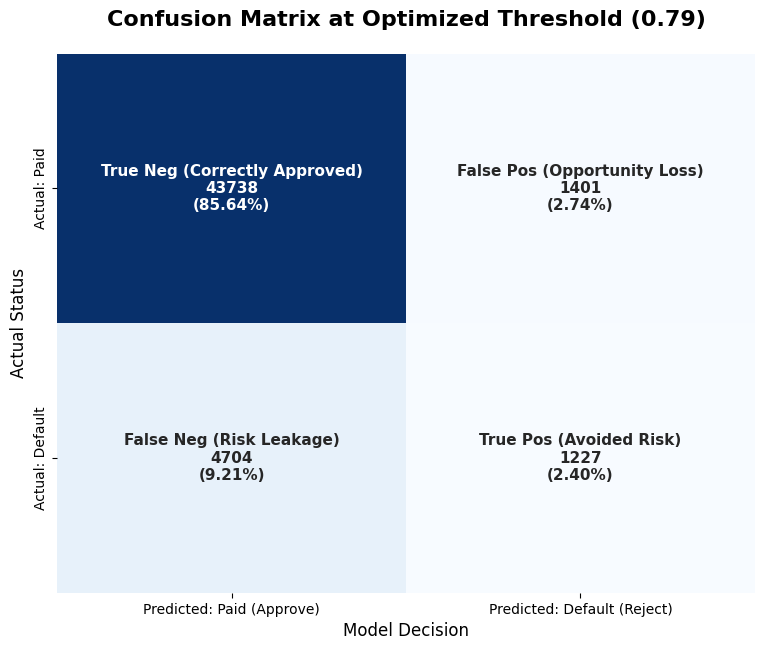

In [67]:
# VISUALIZATION (HEATMAP)
plt.figure(figsize=(9, 7))

# Labels for each quadrant
group_names = ['True Neg (Correctly Approved)', 'False Pos (Opportunity Loss)',
               'False Neg (Risk Leakage)', 'True Pos (Avoided Risk)']

# Raw counts
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# Percentages
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

# Combine labels
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# Plotting
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Paid (Approve)', 'Predicted: Default (Reject)'],
            yticklabels=['Actual: Paid', 'Actual: Default'],
            annot_kws={"size": 11, "weight": "bold"})

plt.title(f'Confusion Matrix at Optimized Threshold ({optimized_threshold})', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Status', fontsize=12)
plt.xlabel('Model Decision', fontsize=12)
plt.show()

In [68]:
# PRINT TEXT REPORT
print("\n📋 CLASSIFICATION REPORT (Threshold 0.79):")
print(classification_report(y_test, y_pred_opt, target_names=['Paid (0)', 'Default (1)']))

# Business Interpretation
tn, fp, fn, tp = cm.ravel()
print("-" * 60)
print("🔍 BUSINESS INTERPRETATION:")
print(f"✅ Correctly Approved (TN): {tn} applicants (Secured Revenue)")
print(f"🚀 Correctly Rejected (TP): {tp} applicants (Avoided Losses)")
print(f"⚠️ Missed/Leakage (FN)    : {fn} applicants (Risk Exposure)")
print(f"📉 Wrongly Rejected (FP)  : {fp} applicants (Opportunity Cost)")
print("-" * 60)


📋 CLASSIFICATION REPORT (Threshold 0.79):
              precision    recall  f1-score   support

    Paid (0)       0.90      0.97      0.93     45139
 Default (1)       0.47      0.21      0.29      5931

    accuracy                           0.88     51070
   macro avg       0.68      0.59      0.61     51070
weighted avg       0.85      0.88      0.86     51070

------------------------------------------------------------
🔍 BUSINESS INTERPRETATION:
✅ Correctly Approved (TN): 43738 applicants (Secured Revenue)
🚀 Correctly Rejected (TP): 1227 applicants (Avoided Losses)
⚠️ Missed/Leakage (FN)    : 4704 applicants (Risk Exposure)
📉 Wrongly Rejected (FP)  : 1401 applicants (Opportunity Cost)
------------------------------------------------------------
